First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

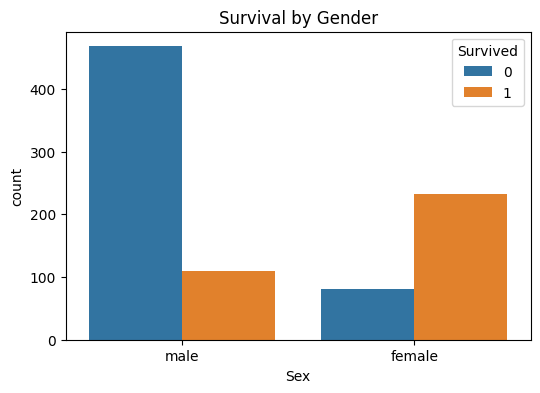

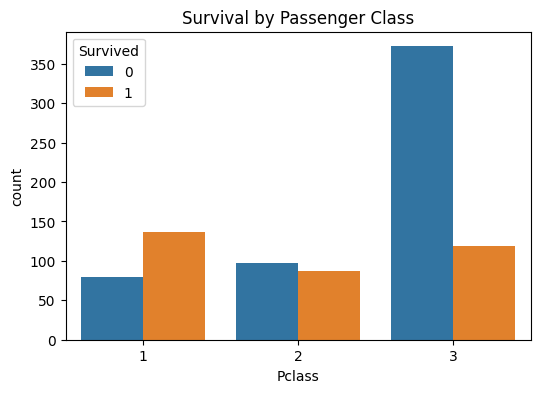

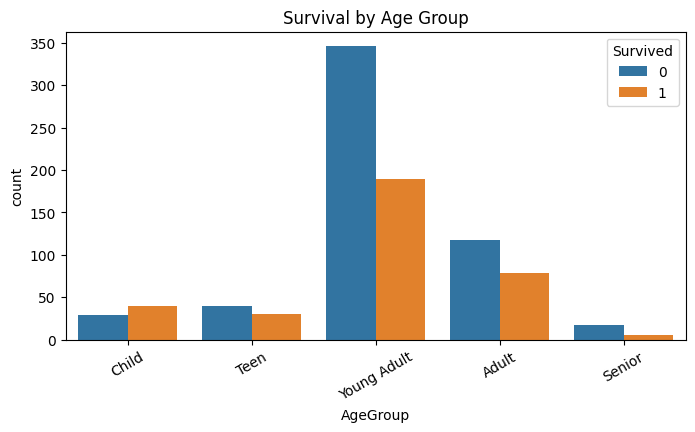

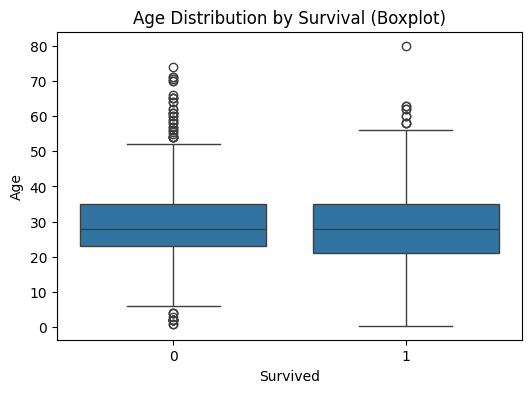

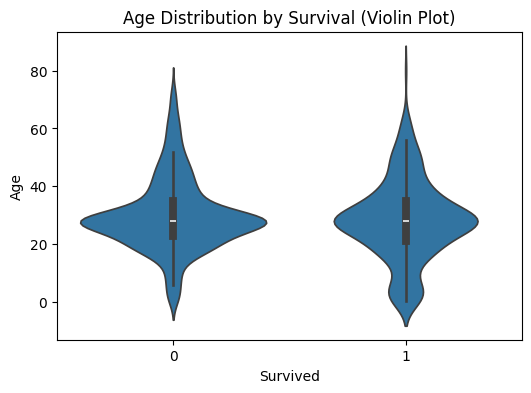

 Key Insight
1. Females had significantly higher survival rates compared to males.
2. Passengers in higher classes, especially 1st class, had better survival outcomes.
3. Children showed higher survival rates, while adults and young adults had lower survival.
4. Age alone does not strongly influence survival, as distributions overlap significantly.
5. 3rd class male passengers appear to be the most vulnerable group with the lowest survival.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load Dataset

df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n", df.describe())


# 2. Missing Values Check

print("\nMissing Values:\n", df.isnull().sum())


# 3. Handle Missing Values (FIXED)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

print("\nMissing Values After Cleaning:\n", df.isnull().sum())


# 4. Create Age Groups

bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


# 5. Survival Analysis Plots


# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Survival by Age Group
plt.figure(figsize=(8,4))
sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.title("Survival by Age Group")
plt.xticks(rotation=30)
plt.show()


# 6. Age Distribution Analysis


# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival (Boxplot)")
plt.show()

# Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival (Violin Plot)")
plt.show()


# 7. Final Insights

print(" Key Insight")

print("1. Females had significantly higher survival rates compared to males.")
print("2. Passengers in higher classes, especially 1st class, had better survival outcomes.")
print("3. Children showed higher survival rates, while adults and young adults had lower survival.")
print("4. Age alone does not strongly influence survival, as distributions overlap significantly.")
print("5. 3rd class male passengers appear to be the most vulnerable group with the lowest survival.")